# Example: Spectral-Assisted LAP Tracking Analysis

This notebook demonstrates the spectral-assisted LAP (Linear Assignment Problem) tracker
for linking single-molecule localisations across frames using both spatial proximity
and colour (spectral) information.

**Input:** `.h5` localisation database produced by `SR_Functions.fit_SM_data()` or similar,
containing columns: `frame, xc, yc, s_x, s_y, bg_B, bg_G, bg_R, A_B, A_G, A_R, chi_sqr`
and corresponding error columns.

**Algorithm:** Jaqaman et al. (2008) Nat. Methods 5, 695-702, extended with spectral
distance in normalised RGB space.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys

sys.path.append("../..")

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import SM_extractionfunctions
SM_E = SM_extractionfunctions.extract_SMs()

from src import HelperFunctions
H_F = HelperFunctions.Helper_Functions()

from src import PlottingBase
plotter = PlottingBase.PublicationPlotter()

from copy import copy

In [42]:
import sys
import tifffile
sys.path.insert(0, "/home/jsb92/Documents/pyDiffusion_LeeLab/src")
from CVE_Functions import CVE as CVE_class
cve = CVE_class()
from sklearn.cluster import KMeans

## 1. Load localisation data

Point `data_folder` at a directory containing `.h5` localisation files
produced by `fit_SM_data()`. Each file should contain one FOV of tracking data.

In [43]:
# --- USER: Set your data path here ---
data_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260324_LipidBilayers/AF488ICAM1_AF555CD58_JF646UCHT1"

localisation_files = H_F.file_search(data_folder, ".h5", "")
print(f"Found {len(localisation_files)} localisation file(s)")

Found 31 localisation file(s)


## 2. Quality filter parameters

These are passed to `filter_quality_localisations()` internally.

In [44]:
# Quality filters
chi_val = 2.0
max_localisation_error = 1.5   # pixels
max_colour_error = 0.15
min_photons = 100
max_photons = 1e6

# Linking parameters
max_distance = 10.0    # pixels — maximum spatial jump per frame
max_dark_time = 3     # frames — maximum gap before track is terminated

# Spectral weighting
w_spatial = 1.0       # weight for spatial cost term
w_spectral = 1.0      # weight for spectral cost term
spectral_tol = 0.15   # normalisation scale for spectral distance

## 3. Run spectral LAP linking — all FOVs

Loop over every localisation file, link each independently, tag with the full file path
as `fov_name`, offset `molecular_index` to be globally unique, then concatenate into
combined single-molecule (`sm_db_all`) and single-frame (`sf_db_all`) databases.

In [45]:
all_sm = []
all_sf = []
running_idx_offset = 0
min_frames = 10

for f in localisation_files:
    fov_name = f  # full path as unique FOV identifier
    print(f"Processing: {os.path.basename(f)}")

    loc_data = pd.read_hdf(f)

    sm, sf = SM_E.extract_single_molecules_spectral_lap(
        loc_data.copy(),
        max_distance=max_distance,
        max_dark_time=max_dark_time,
        w_spatial=w_spatial,
        w_spectral=w_spectral,
        spectral_tol=spectral_tol,
        chi_val=chi_val,
        max_localisation_error=max_localisation_error,
        max_colour_error=max_colour_error,
        min_photons=min_photons,
        max_photons=max_photons,
        verbose=False,
    )

    sm = sm[sm['frames'] > min_frames].copy()
    sf = sf[sf['molecular_index'].isin(sm['molecular_index'])].copy()

    sm['molecular_index'] += running_idx_offset
    sf['molecular_index'] += running_idx_offset
    sm['fov_name'] = fov_name
    sf['fov_name'] = fov_name

    running_idx_offset = int(sm['molecular_index'].max()) + 1

    all_sm.append(sm)
    all_sf.append(sf)
    print(f"  -> {len(sm)} molecules")

sm_db = pd.concat(all_sm, ignore_index=True)
sf_db = pd.concat(all_sf, ignore_index=True)

print(f"\nTotal: {len(sm_db)} molecules from {len(localisation_files)} FOVs")

Processing: 4banddichroic_NF_1_MMStack_Default.h5
  -> 39 molecules
Processing: 4banddichroic_NF_2_MMStack_Default.h5
  -> 36 molecules
Processing: 4banddichroic_NF_3_MMStack_Default.h5
  -> 107 molecules
Processing: 4banddichroic_NF_4_MMStack_Default.h5
  -> 92 molecules
Processing: 4banddichroic_NF_5_MMStack_Default.h5
  -> 57 molecules
Processing: 4banddichroic_NF_6_MMStack_Default.h5
  -> 48 molecules
Processing: 4banddichroic_NF_1_MMStack_Default.h5
  -> 29 molecules
Processing: 4banddichroic_NF_2_MMStack_Default.h5
  -> 43 molecules
Processing: 4banddichroic_NF_3_MMStack_Default.h5
  -> 89 molecules
Processing: 4banddichroic_NF_4_MMStack_Default.h5
  -> 55 molecules
Processing: 4banddichroic_NF_5_MMStack_Default.h5
  -> 58 molecules
Processing: 4banddichroic_NF_6_MMStack_Default.h5
  -> 37 molecules
Processing: 4banddichroic_NF_1_MMStack_Default.h5
  -> 35 molecules
Processing: 4banddichroic_NF_2_MMStack_Default.h5
  -> 59 molecules
Processing: 4banddichroic_NF_3_MMStack_Default.

## 4. Inspect the results

/tmp/ipykernel_1059285/2252843957.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


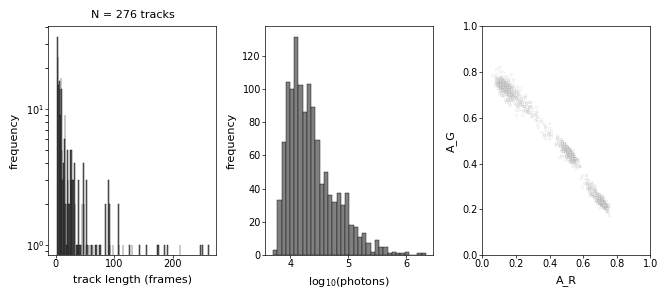

In [48]:
# Track length distribution
track_lengths = sf_db.groupby("molecular_index").size()

fig, axs = plotter.two_column_plot(ncols=3)

# Track lengths
bins = np.arange(0.5, track_lengths.max() + 1.5, 1)
axs[0].hist(track_lengths, bins=bins, color="gray", edgecolor="black", linewidth=0.3)
axs[0].set_xlabel("track length (frames)")
axs[0].set_ylabel("frequency")
axs[0].set_yscale('log')
axs[0].set_title(f"N = {len(track_lengths)} tracks")

# Photons per molecule
bins_ph = np.histogram_bin_edges(np.log10(sm_db["photons"].to_numpy()), "sqrt")
axs[1].hist(np.log10(sm_db["photons"]), bins=bins_ph, color="gray", edgecolor="black", linewidth=0.3)
axs[1].set_xlabel(r"log$_{10}$(photons)")
axs[1].set_ylabel("frequency")

# Colour distribution (per molecule)
axs[2].scatter(sm_db["A_R"], sm_db["A_G"], s=3, alpha=0.25, c="white", edgecolors="gray", linewidth=0.3)
axs[2].set_xlabel("A_R")
axs[2].set_ylabel("A_G")
axs[2].set_xlim([0, 1])
axs[2].set_ylim([0, 1])

plt.tight_layout()
#plt.savefig('For_Dan.svg', dpi=600, format='svg')
plt.show()

## 5. Visualise trajectories

Plot spatial trajectories coloured by their average RGB values.

In [72]:
len(sm_db)

1249

/tmp/ipykernel_1059285/281603242.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


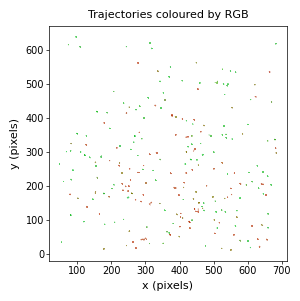

In [38]:
fig, ax = plotter.create_figure(figsize=(3, 3))

for mol_idx in np.unique(sm_db["molecular_index"].values):
    track = sf_db[sf_db["molecular_index"] == mol_idx].sort_values("frame")
    if len(track) < 11:
        continue

    # Use track colour as line colour
    r = track["A_R"].mean()
    g = track["A_G"].mean()
    b = track["A_B"].mean()
    total = r + g + b
    if total > 0:
        color = np.clip([r / total, g / total, b / total], 0, 1)
    else:
        color = [0.5, 0.5, 0.5]

    ax.plot(track["xc"], track["yc"], lw=0.5, alpha=0.7, color=color)

ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_aspect("equal")
ax.set_title("Trajectories coloured by RGB")
plt.tight_layout()
plt.show()

## 6. Compare with greedy nearest-neighbour linking

Run the standard (non-spectral) linker for comparison.

## 9. Colour clustering

Assign each molecule to one of three colour clusters using KMeans on normalised
(A_R, A_G, A_B). Clusters are ordered by mean A_R so that:
- **Cluster 0** → lowest A_R (AF488, blue channel dominant)
- **Cluster 1** → intermediate (AF555, green channel dominant)
- **Cluster 2** → highest A_R (JF646, red channel dominant)

The sanity-check scatter (A_R vs A_G) should show three well-separated clouds.

In [47]:
# Normalise colour fractions to sum to 1 per molecule
colour_feat = sm_db[["A_R", "A_G", "A_B"]].to_numpy().astype(float)
row_sums = colour_feat.sum(axis=1, keepdims=True)
colour_norm = colour_feat / np.where(row_sums > 0, row_sums, 1.0)

# Fit KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(colour_norm)

# Order clusters by ascending mean A_R: 0 = bluest (AF488), 2 = reddest (JF646)
mean_AR = [colour_norm[labels == k, 0].mean() for k in range(3)]
order = np.argsort(mean_AR)   # indices of clusters sorted low→high A_R
remap = {int(old): int(new) for new, old in enumerate(order)}
sm_db["colour_cluster"] = np.array([remap[l] for l in labels], dtype=int)

# Propagate cluster labels to sf_db via molecular_index
cluster_map = sm_db.set_index("molecular_index")["colour_cluster"]
sf_db["colour_cluster"] = sf_db["molecular_index"].map(cluster_map)

print("Molecules per cluster:")
print(sm_db["colour_cluster"].value_counts().sort_index())

Molecules per cluster:
colour_cluster
0    497
1    370
2    382
Name: count, dtype: int64


/tmp/ipykernel_1059285/3836954472.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


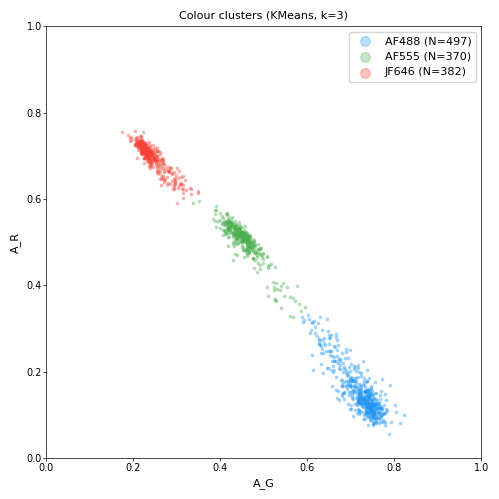

In [51]:
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red
cluster_names  = ["AF488", "AF555", "JF646"]

# Sanity-check scatter: A_R vs A_G coloured by assigned cluster
fig, ax = plotter.create_figure(figsize=(5, 5))
for k in range(3):
    mask = sm_db["colour_cluster"] == k
    ax.scatter(sm_db.loc[mask, "A_G"], sm_db.loc[mask, "A_R"],
               s=3, alpha=0.3, color=cluster_colors[k],
               label=f"{cluster_names[k]} (N={mask.sum()})")
ax.set_xlabel("A_G")
ax.set_ylabel("A_R")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.legend(markerscale=4, fontsize=8)
ax.set_title("Colour clusters (KMeans, k=3)")
plt.tight_layout()
plt.show()

## 10. CVE diffusion coefficient per molecule

For each molecule with at least `min_frames_cve` localisations, estimate the
2D diffusion coefficient using the Covariance-Based Estimator (CVE) of Vestergaard
et al. (Phys. Rev. E 2014, 89, 022726). Positions are converted to nm before passing
to the estimator so D comes out in nm² s⁻¹, then converted to μm² s⁻¹.

Tracks with frame gaps are treated as uniformly sampled — a valid approximation when
`max_dark_time` is small relative to track length.

In [66]:
# --- USER: set physical parameters ---
pixel_size_nm = 69.0   # nm per pixel
frame_time_s  = 0.5    # seconds per frame
R_blur        = 1.0 / 6  # motion blur coefficient (camera exposure / frame time)
min_frames_cve = 8    # minimum track length for a CVE estimate

cve_records = []
for _, row in sm_db.iterrows():
    track = sf_db[sf_db["molecular_index"] == row["molecular_index"]].sort_values("frame")
    if len(track) < min_frames_cve:
        continue

    x_nm = track["xc"].to_numpy() * pixel_size_nm
    y_nm = track["yc"].to_numpy() * pixel_size_nm
    coords = np.column_stack([x_nm, y_nm])   # shape (N, 2)

    D, sigma = cve.DSigma_CVE(coords, frame_time_s, R=R_blur, n_d=2,
                               min_points=min_frames_cve)
    cve_records.append({
        "molecular_index": row["molecular_index"],
        "D_nm2_s":         D,
        "sigma_nm":        sigma,
        "colour_cluster":  row["colour_cluster"],
        "fov_name":        row["fov_name"],
        "frames":          row["frames"],
        "photons":         row["photons"],
    })

cve_df = pd.DataFrame(cve_records)
cve_df["D_um2_s"] = cve_df["D_nm2_s"] / 1e6

# Keep physically plausible values (0 < D < 100 μm²/s)
cve_df = cve_df[(cve_df["D_um2_s"] > 0) & (cve_df["D_um2_s"] < 1000)].copy()

print(f"CVE estimates: {len(cve_df)} molecules")
print(cve_df.groupby("colour_cluster")["D_um2_s"].describe().round(4))

CVE estimates: 92 molecules
                count    mean     std  min     25%     50%     75%     max
colour_cluster                                                            
0                44.0  0.0006  0.0009  0.0  0.0001  0.0003  0.0008  0.0045
1                15.0  0.0009  0.0015  0.0  0.0002  0.0004  0.0011  0.0057
2                33.0  0.0005  0.0010  0.0  0.0001  0.0002  0.0004  0.0056


/home/jsb92/Documents/pyDiffusion_LeeLab/src/CVE_Functions.py:156: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(np.multiply(R, deltaX_sqr) + np.multiply((2 * R - 1), mult))


/tmp/ipykernel_1059285/611610091.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


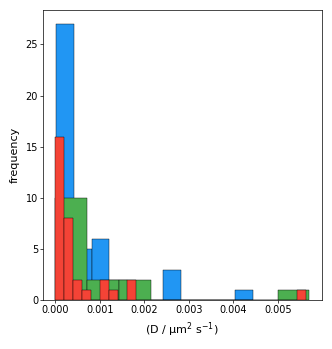

In [71]:
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red
cluster_names  = ["AF488", "AF555", "JF646"]

fig, axs = plotter.one_column_plot(npanels=1)

for k in range(3):
    d_vals = cve_df.loc[cve_df["colour_cluster"] == k, "D_um2_s"].dropna()
    d_pos = d_vals[d_vals > 0]
    if len(d_pos) < 2:
        continue
    bins = np.histogram_bin_edges(d_pos, "fd")
    axs.hist(d_pos, bins=bins, color=cluster_colors[k],
                edgecolor="black", linewidth=0.3)
    axs.set_xlabel(r"(D / μm$^2$ s$^{-1}$)")
    axs.set_ylabel("frequency")
    median_D = float(np.median(d_pos))

plt.tight_layout()
plt.show()

## 11. Raw image overlay

Load the raw TIFF for one FOV, max-project the first 100 frames, and overlay
single-molecule positions as open circles coloured by their `colour_cluster` identity.
Change `fov_index` to inspect a different field of view.

In [ ]:
# --- USER: set FOV to display (index into localisation_files) ---
fov_index = 0
fov_to_show = localisation_files[fov_index]

# Infer TIFF path from .h5 path (try .ome.tif then .tif)
tiff_path = fov_to_show.replace(".h5", ".ome.tif")
if not os.path.exists(tiff_path):
    tiff_path = fov_to_show.replace(".h5", ".tif")

# Load and max-project first 100 frames
with tifffile.TiffFile(tiff_path) as tif:
    n_frames = min(100, len(tif.pages))
    stack = tif.asarray(key=range(n_frames))

img = stack.max(axis=0) if stack.ndim == 3 else stack

# Localisations for this FOV only
sm_fov = sm_db[sm_db["fov_name"] == fov_to_show]

cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red
cluster_names  = ["AF488", "AF555", "JF646"]

fig, ax = plotter.create_figure(figsize=(8, 8))
ax.imshow(img, cmap="gray",
          vmin=np.percentile(img, 1), vmax=np.percentile(img, 99.5),
          origin="upper")

for k in range(3):
    locs = sm_fov[sm_fov["colour_cluster"] == k]
    ax.scatter(locs["xc"], locs["yc"], s=40, facecolors="none",
               edgecolors=cluster_colors[k], linewidths=0.8,
               label=f"{cluster_names[k]} (N={len(locs)})")

ax.legend(loc="upper right", fontsize=8)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title(os.path.basename(fov_to_show))
plt.tight_layout()
plt.show()

## 8. Save results

In [ ]:
# Save combined single-molecule and single-frame databases
output_folder = data_folder

sm_db.to_hdf(
    os.path.join(output_folder, "spectral_lap_single_molecules.h5"),
    key="data", format="table",
)
sf_db.to_hdf(
    os.path.join(output_folder, "spectral_lap_single_frames.h5"),
    key="data", format="table",
)

print(f"Saved to {output_folder}")
print(f"  spectral_lap_single_molecules.h5  ({len(sm_db)} molecules from {sm_db['fov_name'].nunique()} FOVs)")
print(f"  spectral_lap_single_frames.h5     ({len(sf_db)} localisations)")